In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
csv_path = Path(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\housing.csv')
df = pd.read_csv(csv_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
df_copy = df
df_copy['abs_longitude'] = abs(df_copy['longitude'])

In [6]:
df_copy.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,abs_longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,119.569704
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,2.003532
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,114.310000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,118.010000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,118.490000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,121.800000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,124.350000


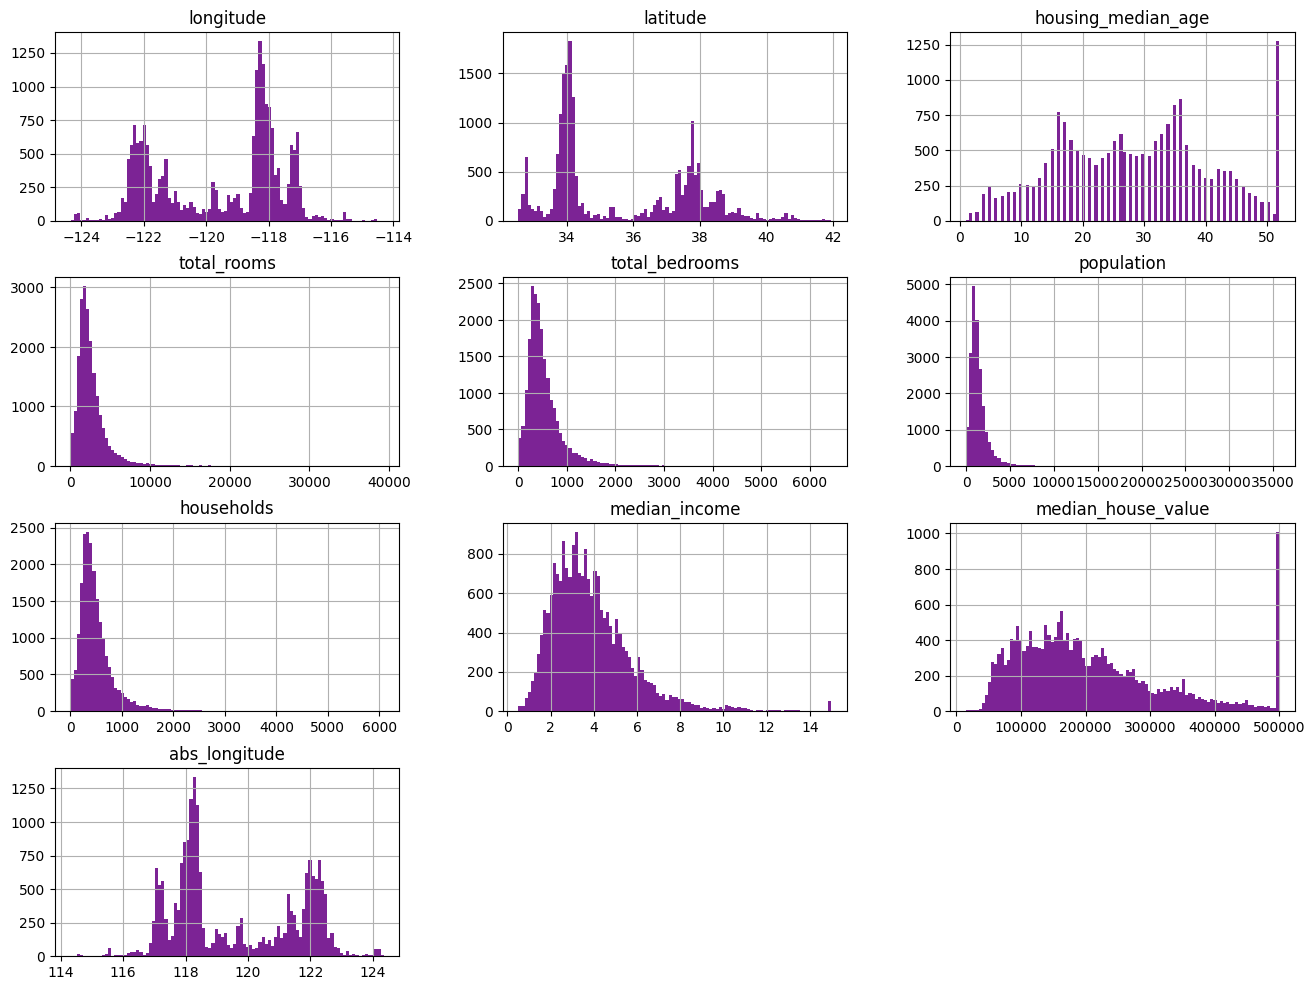

In [7]:
df_copy.hist(bins=100, figsize=(16, 12), color="#7C2395")
plt.show()

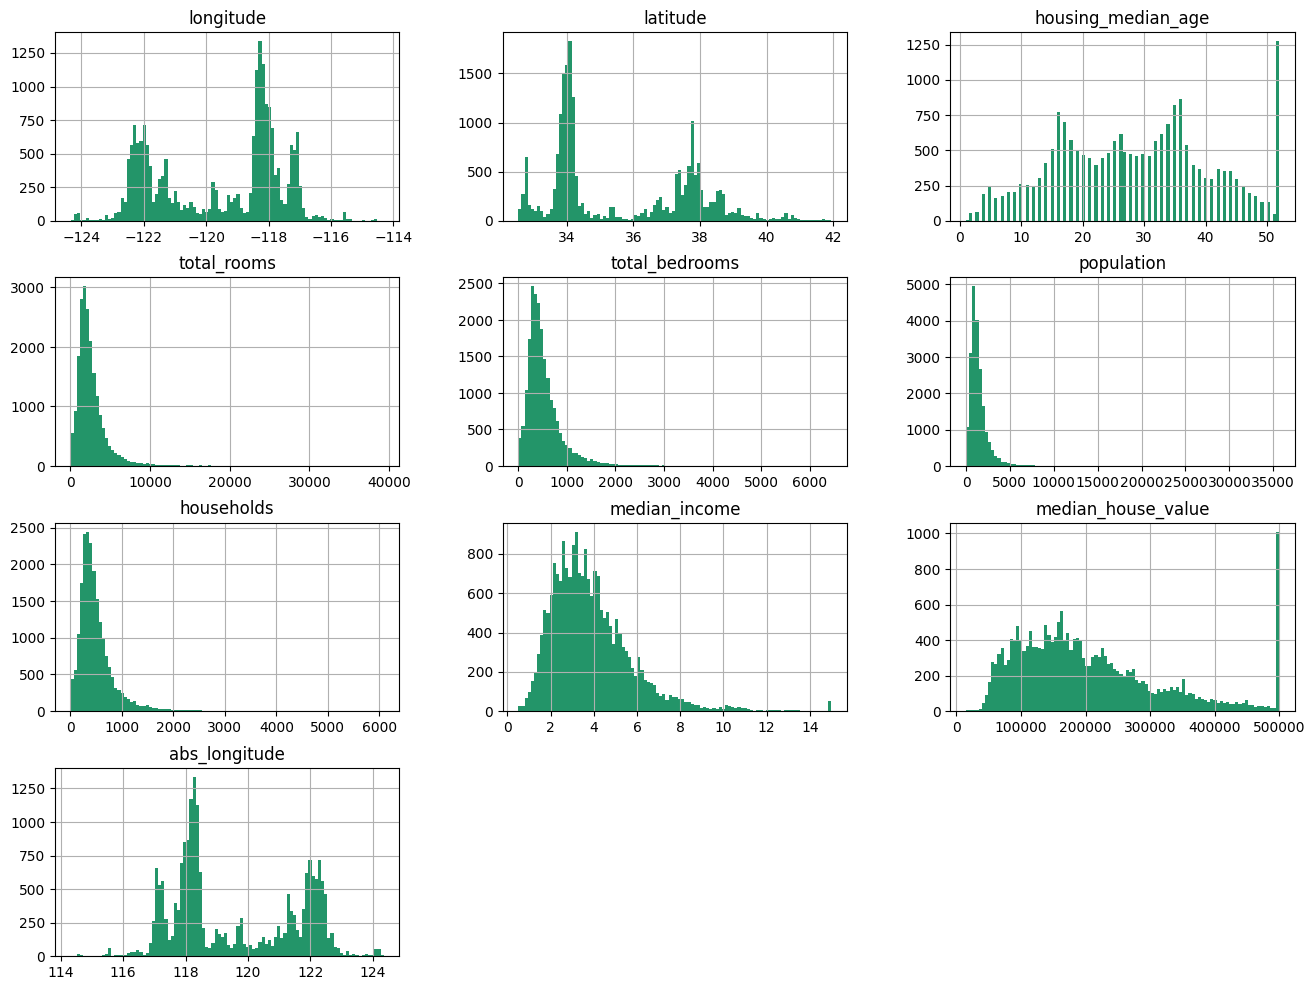

In [8]:
df.hist(bins=100, figsize=(16, 12), color="#239569")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2)
train_set.shape, test_set.shape

((16512, 11), (4128, 11))

In [10]:
df['median_income']

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: median_income, Length: 20640, dtype: float64

In [11]:
df['income_cat'] = pd.cut(
    df['median_income'],
    bins=[0, 1.5, 3, 4.5, 6, np.inf],
    labels=[1, 2, 3, 4, 5],
)

df[['income_cat', 'median_income']].head()

,income_cat,median_income
0,5,8.3252
1,5,8.3014
2,5,7.2574
3,4,5.6431
4,3,3.8462


In [12]:
ic = df['income_cat'].value_counts().sort_index()
ic

income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64

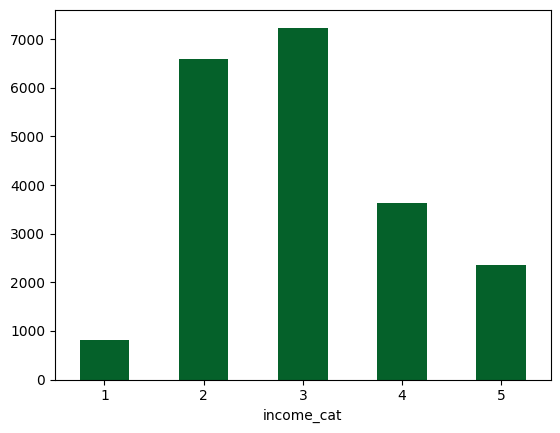

In [13]:
ic.plot.bar(rot=0, color="#05612A");

In [14]:
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2, stratify=df['income_cat'])

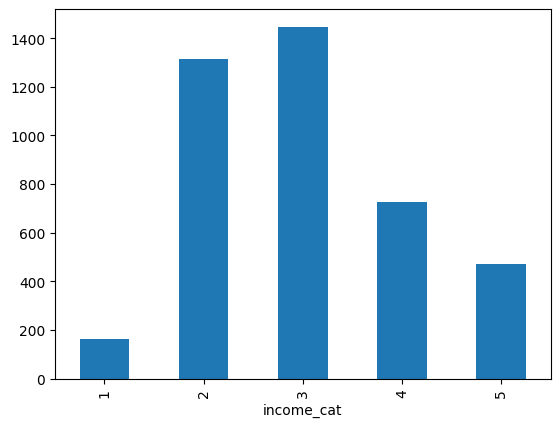

In [19]:
(
    strat_test_set['income_cat']
    .value_counts()
    .sort_index()
    .plot.bar()
);

In [16]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'abs_longitude', 'income_cat'],
      dtype='object')

In [17]:
import plotly.express as px
map_style="open-street-map"
fig = px.scatter_map(
    df, 
    'latitude',
    'longitude',
    color='median_house_value',
    color_continuous_scale='viridis',
    size='population',
    size_max=15, 
    zoom=4,
    opacity=0.5
)

fig.update_layout(
    margin={'l':0,'r':0,'t':0,'b':0},
    width=800
)

In [18]:
corr_matrix = df.corr(numeric_only='number')
corr_matrix['median_house_value'].sort_values()

latitude             -0.144160
longitude            -0.045967
population           -0.024650
abs_longitude         0.045967
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [20]:
corr_matrix['households'].sort_values()

housing_median_age   -0.302916
latitude             -0.071035
abs_longitude        -0.055310
median_income         0.013033
longitude             0.055310
median_house_value    0.065843
population            0.907222
total_rooms           0.918484
total_bedrooms        0.979728
households            1.000000
Name: households, dtype: float64

In [21]:
corr_matrix['latitude'].sort_values()

longitude            -0.924664
median_house_value   -0.144160
population           -0.108785
median_income        -0.079809
households           -0.071035
total_bedrooms       -0.066983
total_rooms          -0.036100
housing_median_age    0.011173
abs_longitude         0.924664
latitude              1.000000
Name: latitude, dtype: float64

In [24]:
cov = np.cov(df['latitude'], df['longitude'])

In [31]:
cov[0, 1]

np.float64(-3.9570537213405705)

In [26]:
mean_lat = np.mean(df['latitude'])
mean_long = np.mean(df['longitude'])

In [32]:
dev_lat = (df['latitude'] - mean_lat)
dev_long = (df['longitude'] - mean_long)
n = len(df) - 1

In [33]:
cov_cal = np.sum(dev_lat * dev_long) / (n)

In [34]:
cov_cal

np.float64(-3.9570537213405714)

In [39]:
std_lat = np.sqrt(np.sum(dev_lat ** 2) / n)
std_long = np.sqrt(np.sum(dev_long ** 2) / n)

In [40]:
corr = cov_cal / (std_lat * std_long)

In [41]:
corr

np.float64(-0.9246644339150409)

In [42]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,abs_longitude
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967,-1.000000
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160,0.924664
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623,0.108197
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153,-0.044568
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,-0.069608
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650,-0.099773
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843,-0.055310
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075,0.015176
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000,0.045967
abs_longitude,-1.000000,0.924664,0.108197,-0.044568,-0.069608,-0.099773,-0.055310,0.015176,0.045967,1.000000


In [48]:
fig2 = px.imshow(
    corr_matrix,
    color_continuous_scale='RdBu',
    text_auto=".2f",
    aspect='auto'
)

fig2.update_layout(margin={'t':10, 'b':5}, width=800)

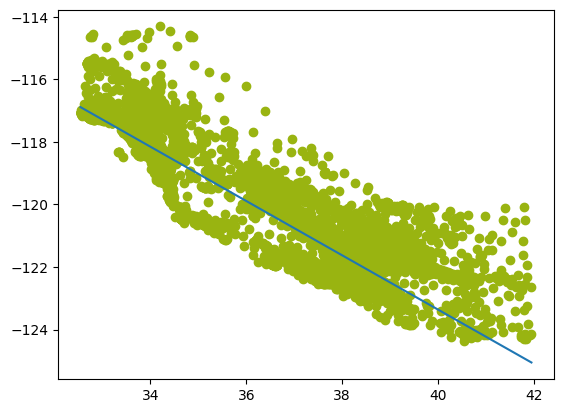

In [61]:
x_data = df['latitude']
y_data = df['longitude']

# scatter
plt.scatter(x_data, y_data, color="#99b411")

# regression coefficients
a, b = np.polyfit(x_data, y_data, 1)

# regression line
x = np.linspace(x_data.min(), x_data.max(), 200)
y = a * x + b

plt.plot(x, y)
plt.show()